In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from datetime import datetime
import plotly.express as px

mpl.rc('font',family='Malgun Gothic')

##### 데이터 불러오기

In [3]:
df1 = pd.read_csv('oil_price.csv')

##### 데이터의 구조와 타입 확인

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 574042 entries, 0 to 574041
Data columns (total 11 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   번호      574042 non-null  object 
 1   지역      574042 non-null  object 
 2   상호      574042 non-null  object 
 3   주소      574042 non-null  object 
 4   기간      574042 non-null  object 
 5   상표      574042 non-null  object 
 6   셀프여부    574042 non-null  object 
 7   고급휘발유   574042 non-null  float64
 8   휘발유     574042 non-null  float64
 9   경유      574042 non-null  float64
 10  실내등유    574042 non-null  float64
dtypes: float64(4), object(7)
memory usage: 48.2+ MB


##### 컬럼명 영어로 변환 및 날짜 데이터 타입 변환

In [ ]:
# 컬럼명 영어로 변환
df1 = df1.rename(columns={
    '번호': 'id',
    '지역': 'region',
    '상호': 'store_name', 
    '주소': 'address',
    '기간': 'period',
    '상표': 'brand',
    '셀프여부': 'is_self',
    '고급휘발유': 'premium_gas',
    '휘발유': 'regular_gas',
    '경유': 'diesel',
    '실내등유': 'kerosene'
})

# 날짜 데이터 타입 변환
for week_num, date_name in enumerate(sorted(df1.period.unique()), start=1):
    name = date_name.split()
    year, month = int(name[0][:4]), int(name[1][:2])

    date = datetime.strptime(f"{year}-{month}-0-{week_num}", "%Y-%m-%w-%U")

    df1.loc[df1['period'] == date_name, 'period'] = date

df1.head(2)

,id,region,store_name,address,period,brand,is_self,premium_gas,regular_gas,diesel,kerosene
0,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-02 00:00:00,현대오일뱅크,셀프,1769.0,1543.0,1375.86,0.0
1,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-09 00:00:00,현대오일뱅크,셀프,1769.0,1543.0,1368.00,0.0


##### 상위 5개 데이터 추출(데이터셋 구조 확인)

In [6]:
df1.head() # 상위 5개 데이터 추출

,id,region,store_name,address,period,brand,is_self,premium_gas,regular_gas,diesel,kerosene
0,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-02 00:00:00,현대오일뱅크,셀프,1769.00,1543.00,1375.86,0.0
1,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-09 00:00:00,현대오일뱅크,셀프,1769.00,1543.00,1368.00,0.0
2,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-16 00:00:00,현대오일뱅크,셀프,1769.00,1568.00,1389.43,0.0
3,A0033584,강원 강릉시,(주)강릉햇살 유천주유소,강원도 강릉시 사임당로 178(유천동),2022-01-23 00:00:00,현대오일뱅크,셀프,1777.57,1579.43,1408.71,0.0
4,A0011352,강원 강릉시,(주)대성길,강원 강릉시 구정면 칠성로 187,2022-01-02 00:00:00,S-OIL,셀프,0.00,1599.00,1449.00,1080.0


##### 각 oil별 평균 금액 계산

In [27]:
oil_type = df1[['premium_gas', 'regular_gas', 'diesel', 'kerosene']]
pd.DataFrame(oil_type.mean(), columns=['mean_price']) # 데이터 프레임 형태로 나타냄

,mean_price
premium_gas,242.676115
regular_gas,1806.883411
diesel,1843.348646
kerosene,912.986693


##### 각 지역, 상호별로 입력한 oil type에 따른 평균 금액이 낮은 순서대로 정렬한 표

In [79]:
column_map = {
    'premium gas': 'premium_gas',
    'regular gas': 'regular_gas',
    'diesel': 'diesel',
    'kerosene': 'kerosene',
    '고급휘발유' : 'premium_gas',
    '휘발유' : 'regular_gas',
    '경유' : 'diesel',
    '실내등유' : 'kerosene'
}

oil_type_input = input("oil type을 입력하세요. (ex. 고급휘발유, 휘발유, 경유, 실내등유)")
oil_type = column_map.get(oil_type_input)

if oil_type not in df1.columns:
    print(f"{oil_type} 컬럼이 존재하지 않습니다.")
else:
    filtered_df = df1[df1[oil_type] != 0] # 데이터 값이 0인 경우 제외
    mean_price = filtered_df.pivot_table(
        index=['region','store_name'],
        values=oil_type,
        aggfunc='mean'
        ).sort_values(by=oil_type, ascending=True).reset_index()
    
    mean_price.columns = ['지역', '상호명', f'{oil_type_input} 평균 금액']
    
    display(mean_price)


,지역,상호명,경유 평균 금액
0,경기 부천시,하트주유소,1366.142500
1,경북 경주시,팔공주유소,1371.857500
2,경기 수원시,대륙주유소,1387.000000
3,경기 파주시,아동주유소,1395.000000
4,대구 동구,천광주유소,1397.200000
...,...,...,...
11328,서울 용산구,한석주유소,2420.869615
11329,서울 강남구,(주)만정에너지 삼보주유소,2431.653462
11330,서울 중구,필동주유소,2555.576731
11331,서울 중구,서남주유소,2796.875769


##### brand 컬럼의 항목별 개수 확인

In [ ]:
brand_type = pd.DataFrame(df1['brand'].value_counts())
brand_type

,count
brand,
SK에너지,152489
현대오일뱅크,123402
GS칼텍스,113945
S-OIL,110796
NH-OIL,34596
알뜰주유소,22470
알뜰(ex),9780
자가상표,6564


##### 각 brand별 주유소 수 시각화

In [29]:
brand_type.columns = ['count'] 
p1 = brand_type.reset_index() # 인덱스를 컬럼으로 변환
px.bar(p1, x='brand', y='count')

##### period에 따른 oil type별 평균 금액 확인

In [ ]:
period_oil = df1.groupby('period')[['premium_gas', 'regular_gas', 'diesel', 'kerosene']].mean().rename_axis('oil_type', axis=1)
period_oil

oil_type,premium_gas,regular_gas,diesel,kerosene
period,,,,
2022-01-02,206.791195,1615.290995,1439.547888,729.090958
2022-01-09,207.813201,1616.891402,1440.523285,732.091718
2022-01-16,209.016168,1629.218558,1452.814078,738.954610
2022-01-23,210.918266,1647.608632,1472.102829,749.371291
2022-01-30,212.418644,1664.193510,1487.911776,759.246913
2022-02-06,214.473462,1690.619816,1514.525361,775.996701
2022-02-13,216.864186,1717.139243,1543.524126,792.566461
2022-02-20,219.072920,1737.582843,1567.984837,804.734635
2022-02-27,221.737270,1766.626950,1600.237136,815.906921


##### 각 oil type별 가격 추세 그래프

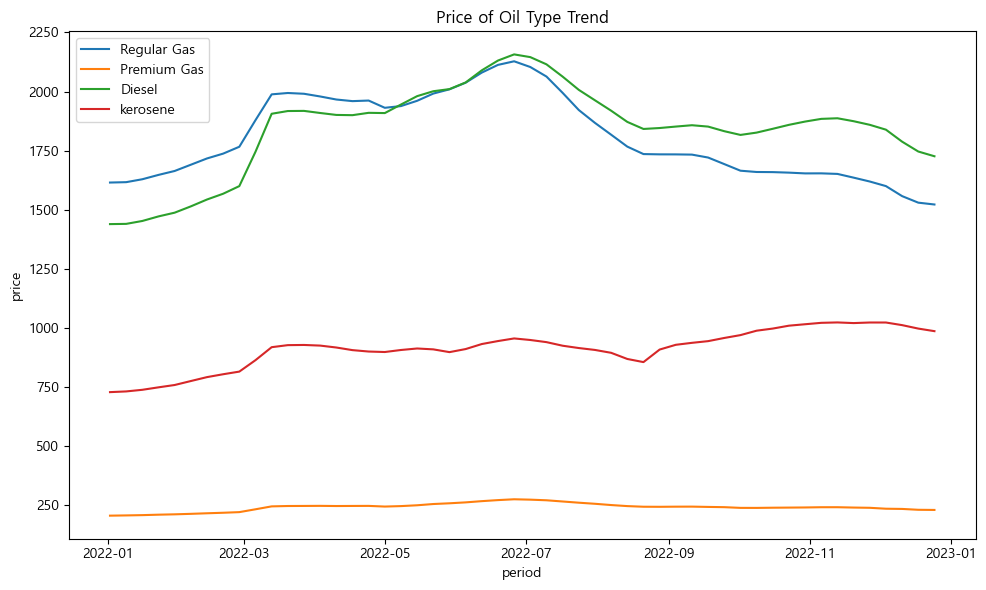

In [38]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=period_oil, x='period',y='regular_gas',label='Regular Gas')
sns.lineplot(data=period_oil, x='period',y='premium_gas',label='Premium Gas')
sns.lineplot(data=period_oil, x='period',y='diesel',label='Diesel')
sns.lineplot(data=period_oil, x='period',y='kerosene', label='kerosene')

plt.title('Price of Oil Type Trend')
plt.ylabel('price')
plt.legend()
plt.tight_layout()
plt.show()

##### region 컬럼 데이터값 확인

In [ ]:
df1['region'].unique()

array(['강원 강릉시', '강원 고성군', '강원 동해시', '강원 삼척시', '강원 속초시', '강원 양구군',
       '강원 양양군', '강원 영월군', '강원 원주시', '강원 인제군', '강원 정선군', '강원 철원군',
       '강원 춘천시', '강원 태백시', '강원 평창군', '강원 홍천군', '강원 화천군', '강원 횡성군',
       '경기 가평군', '경기 고양시', '경기 과천시', '경기 광명시', '경기 광주시', '경기 구리시',
       '경기 군포시', '경기 김포시', '경기 남양주시', '경기 동두천시', '경기 부천시', '경기 성남시',
       '경기 수원시', '경기 시흥시', '경기 안산시', '경기 안성시', '경기 안양시', '경기 양주시',
       '경기 양평군', '경기 여주시', '경기 연천군', '경기 오산시', '경기 용인시', '경기 의왕시',
       '경기 의정부시', '경기 이천시', '경기 파주시', '경기 평택시', '경기 포천시', '경기 하남시',
       '경기 화성시', '경남 거제시', '경남 거창군', '경남 고성군', '경남 김해시', '경남 남해군',
       '경남 밀양시', '경남 사천시', '경남 산청군', '경남 양산시', '경남 의령군', '경남 진주시',
       '경남 창녕군', '경남 창원시', '경남 통영시', '경남 하동군', '경남 함안군', '경남 함양군',
       '경남 합천군', '경북 경산시', '경북 경주시', '경북 고령군', '경북 구미시', '경북 군위군',
       '경북 김천시', '경북 문경시', '경북 봉화군', '경북 상주시', '경북 성주군', '경북 안동시',
       '경북 영덕군', '경북 영양군', '경북 영주시', '경북 영천시', '경북 예천군', '경북 울릉군',
       '경북 울진군', '경북 의성군', '경북 청도군', '경북 청송군', '경북 칠곡군', '경

##### region별 주유소 수 확인

In [48]:
oilbank_count = df1.pivot_table(index='region', values='store_name', aggfunc='count')
oilbank_count

,store_name
region,
강원 강릉시,4292
강원 고성군,926
강원 동해시,1748
강원 삼척시,1625
강원 속초시,1139
...,...
충북 제천시,3695
충북 증평군,898
충북 진천군,3039


##### 특정 지역 이름을 입력하여, 해당 지역의 brand별 주유소 수 확인

In [32]:
region_name = input("지역명을 입력하세요. (ex. 서울 노원구)").strip()
print(region_name)
filter_region = df1[df1['region'] == region_name].drop_duplicates(subset='store_name')
filter_region.pivot_table(index='brand', values='store_name', aggfunc='count')

경기 안산시


,store_name
brand,
GS칼텍스,18
S-OIL,10
SK에너지,24
알뜰주유소,1
자가상표,2
현대오일뱅크,19
